In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [5]:
df = pd.read_csv("creditcard.csv")

In [6]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [7]:
df.isnull().sum()
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [8]:
df.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

In [9]:
df.dtypes.value_counts()

float64    30
int64       1
Name: count, dtype: int64

In [10]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

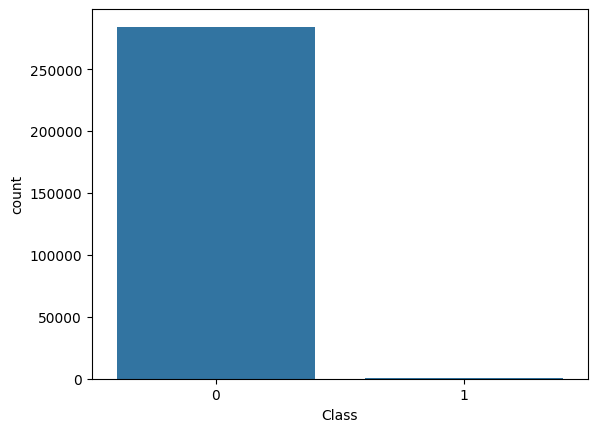

In [11]:
sns.countplot(x='Class', data=df)
plt.show()

## Handling Imbalanced Data

In [12]:
normal = df[df['Class'] == 0]
fraud = df[df['Class'] == 1]

print(normal.shape)
print(fraud.shape)

(284315, 31)
(492, 31)


In [13]:
normal_sample = normal.sample(n=len(fraud), random_state=42)
new_df = pd.concat([normal_sample, fraud], axis=0)

In [14]:
new_df = new_df.sample(frac=1, random_state=42)

In [15]:
new_df['Class'].value_counts()

Class
1    492
0    492
Name: count, dtype: int64

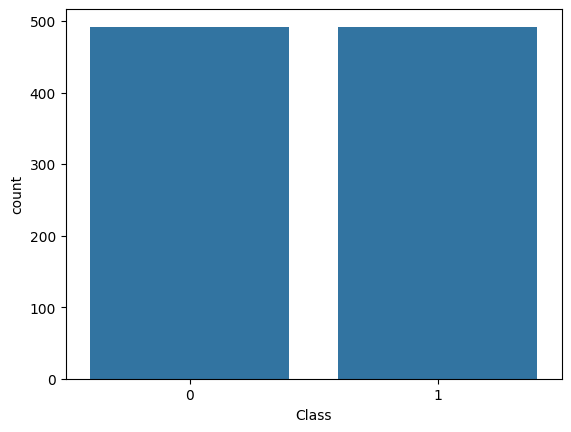

In [16]:
sns.countplot(x='Class', data=new_df)
plt.show()

In [17]:
X = new_df.drop(columns='Class', axis=1)
Y = new_df['Class']

In [18]:
print(X.shape)
print(Y.shape)

(984, 30)
(984,)


<Axes: xlabel='Class', ylabel='Amount'>

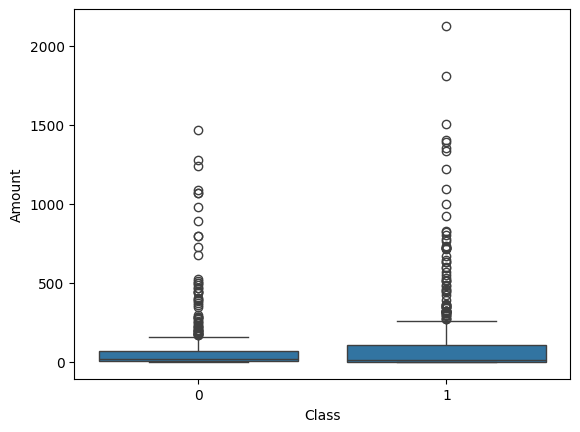

In [19]:
sns.boxplot(
    data = new_df,
    x = 'Class',
    y = 'Amount',
)


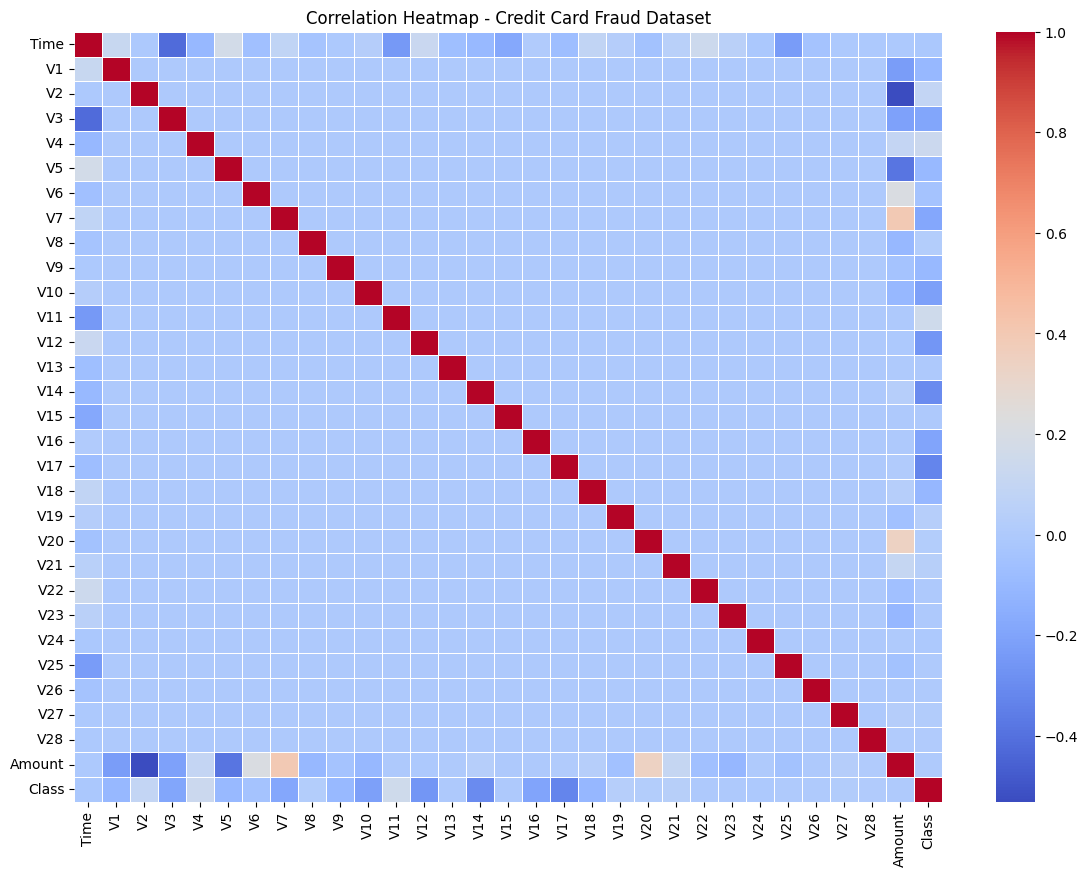

In [64]:
corr_matrix = df.corr()
plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=False,      # True = show numbers (too crowded here)
    linewidths=0.5
)

plt.title("Correlation Heatmap - Credit Card Fraud Dataset")
plt.show()

## Feature Scaling

In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

new_df['scaled_amount'] = scaler.fit_transform(new_df[['Amount']])
new_df['scaled_time'] = scaler.fit_transform(new_df[['Time']])

In [21]:
new_df = new_df.drop(['Time', 'Amount'], axis=1)

## Train-Test Split

In [24]:
X = new_df.drop('Class', axis=1)
Y = new_df['Class']

In [25]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    stratify=Y,
    random_state=42
)

In [26]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [49]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [50]:
Y_pred = model.predict(X_test)

## Model Evaluation

In [51]:
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(Y_test, Y_pred))

Accuracy: 0.9543147208121827


In [57]:
#Logistic Regression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

print("Logistic Regression Model")
print("precision: ",precision_score(Y_test,log_pred))
print("recall: ",recall_score(Y_test,log_pred))
print("f1 score: ",f1_score(Y_test,log_pred))
print("Accurancy: ",accuracy_score(Y_test,log_pred))
print("CM: ",confusion_matrix(Y_test,log_pred))

Logistic Regression Model
precision:  1.0
recall:  0.42857142857142855
f1 score:  0.6
Accurancy:  0.7157360406091371
CM:  [[99  0]
 [56 42]]


In [58]:
#Knn
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=7)

#Train model
knn_model.fit(X_train_scaled, Y_train)

#Prediction
knn_pred = knn_model.predict(X_test_scaled)

#Evaluation
print("KNN Model")
print("precision: ",precision_score(Y_test,knn_pred))
print("recall: ",recall_score(Y_test,knn_pred))
print("f1 score: ",f1_score(Y_test,knn_pred))
print("Accurancy: ",accuracy_score(Y_test,knn_pred))
print("CM: ",confusion_matrix(Y_test,knn_pred))

KNN Model
precision:  0.9772727272727273
recall:  0.8775510204081632
f1 score:  0.9247311827956989
Accurancy:  0.9289340101522843
CM:  [[97  2]
 [12 86]]


In [59]:
#Naive Bayes
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_scaled, Y_train)

nb_pred = nb_model.predict(X_test_scaled)

#Evaluation
print("Naive Bayes Model")
print("precision: ",precision_score(Y_test,nb_pred))
print("recall: ",recall_score(Y_test,nb_pred))
print("f1 score: ",f1_score(Y_test,nb_pred))
print("Accurancy: ",accuracy_score(Y_test,nb_pred))
print("CM: ",confusion_matrix(Y_test,nb_pred))

Naive Bayes Model
precision:  0.9444444444444444
recall:  0.8673469387755102
f1 score:  0.9042553191489362
Accurancy:  0.9086294416243654
CM:  [[94  5]
 [13 85]]


In [61]:
# compare all models
models = {
    "Logistic Regression": log_pred,
    "KNN": knn_pred,
    "Naive Bayes": nb_pred
}

for name, pred in models.items():
    print("------", name, "------")
    print("Precision:", precision_score(Y_test, pred)) 
    print("Recall:", recall_score(Y_test, pred)) 
    print("F1 Score:", f1_score(Y_test, pred)) 
    print("Accuracy:", accuracy_score(Y_test, pred)) 
    print()

------ Logistic Regression ------
Precision: 1.0
Recall: 0.42857142857142855
F1 Score: 0.6
Accuracy: 0.7157360406091371

------ KNN ------
Precision: 0.9772727272727273
Recall: 0.8775510204081632
F1 Score: 0.9247311827956989
Accuracy: 0.9289340101522843

------ Naive Bayes ------
Precision: 0.9444444444444444
Recall: 0.8673469387755102
F1 Score: 0.9042553191489362
Accuracy: 0.9086294416243654



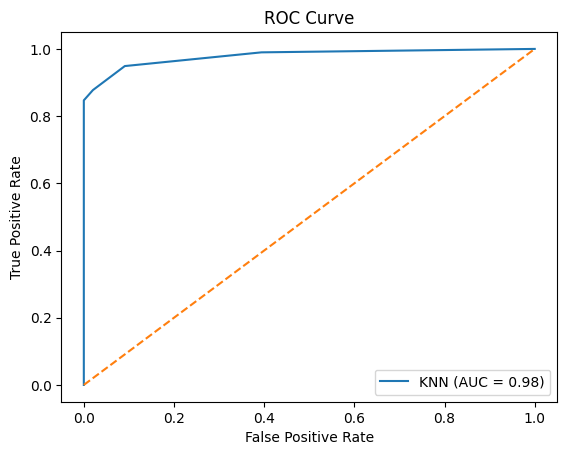

In [62]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = knn_model.predict_proba(X_test_scaled)[:,1]

fpr, tpr, _ = roc_curve(Y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="KNN (AUC = %0.2f)" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [63]:
import joblib
joblib.dump(knn_model, "credit_fraud_model.pkl")

['credit_fraud_model.pkl']